# 📘 Track B — Notebook 1: Environment Setup & HuBERT Feature Extraction

**Project:** Synthetic Data Generation for Speech Emotion Recognition  
**Author:** *(your name)*  
**Purpose:** This notebook is the first stage of a 3-part pipeline.

---

## What This Notebook Does

1. ✅ Verifies environment: GPU, libraries, Python version
2. 📂 Parses your dataset folder structure into a clean metadata index
3. 🎧 Loads each `.wav` file and resamples to 16kHz (required by HuBERT)
4. 🤖 Extracts deep latent embeddings using **facebook/hubert-base-ls960** (pretrained)
5. 📊 Visualizes embedding distributions per emotion using PCA and t-SNE
6. 💾 Saves all embeddings grouped by `(actor, sentence, emotion)` for use in Notebook 2

---

## Dataset Structure Expected

```
my Dataset/
  1/                        ← Actor folder (1–8)
    session1/               ← Session folder (session1–session5)
      anger/                ← Emotion folder
        1.1.anger-01.wav    ← {actor}.{session}.{emotion}-{sentence}.wav
        1.1.anger-02.wav
        ...
      disgust/
      ...
    session2/
    ...
  2/
  ...
  8/
```

**Per (actor, sentence, emotion) group = 5 samples (one per session)**

---

## Output
- `file_index.csv` — metadata for all 3200 files
- `embeddings/` — `.npy` files, one per `(actor, sentence, emotion)` group
- `embeddings/embedding_matrix.npy` — all embeddings stacked (for visualization)
- `embeddings/embedding_labels.csv` — label metadata for each row in the matrix

---
## 🔧 CELL 1 — Install Required Libraries
Run this once. Restart kernel after installation if prompted.

In [4]:
# Install all required packages
# This may take 3–5 minutes on first run
!pip install transformers torchaudio librosa soundfile pandas numpy \
             matplotlib seaborn scikit-learn tqdm -q

print('✅ All packages installed successfully.')

✅ All packages installed successfully.


---
## ✅ CELL 2 — Environment & GPU Health Check

This is a critical pre-flight check. **Do not proceed if GPU is unavailable** unless your dataset is small — HuBERT inference on CPU for 3200 files will take hours.

In [1]:
import sys, os, platform
import torch
import torchaudio
import transformers
import librosa
import numpy as np
import pandas as pd
import matplotlib
import sklearn

print('=' * 55)
print('       ENVIRONMENT & GPU HEALTH CHECK')
print('=' * 55)

print(f'  Python        : {sys.version.split()[0]}')
print(f'  Platform      : {platform.system()} {platform.release()}')
print(f'  PyTorch       : {torch.__version__}')
print(f'  Torchaudio    : {torchaudio.__version__}')
print(f'  Transformers  : {transformers.__version__}')
print(f'  Librosa       : {librosa.__version__}')
print(f'  NumPy         : {np.__version__}')
print(f'  Pandas        : {pd.__version__}')
print(f'  Scikit-learn  : {sklearn.__version__}')
print(f'  Matplotlib    : {matplotlib.__version__}')
print()

# --- GPU Check ---
cuda_available = torch.cuda.is_available()
print(f'  CUDA Available : {cuda_available}')

if cuda_available:
    n_gpus = torch.cuda.device_count()
    print(f'  GPU Count      : {n_gpus}')
    for i in range(n_gpus):
        gpu_name = torch.cuda.get_device_name(i)
        vram = torch.cuda.get_device_properties(i).total_memory / 1e9
        print(f'  GPU [{i}]        : {gpu_name} ({vram:.1f} GB VRAM)')
    device = torch.device('cuda')
    print()
    print('  ✅ GPU is ready. Inference will be fast.')
else:
    device = torch.device('cpu')
    print()
    print('  ⚠️  WARNING: No GPU found. Running on CPU.')
    print('     HuBERT inference on 3200 files may take 1–3 hours on CPU.')
    print('     Consider using Google Colab (free T4 GPU) if needed.')

print('=' * 55)
print(f'  Active device  : {device}')
print('=' * 55)

       ENVIRONMENT & GPU HEALTH CHECK
  Python        : 3.12.10
  Platform      : Windows 11
  PyTorch       : 2.6.0+cu124
  Torchaudio    : 2.6.0+cu124
  Transformers  : 4.57.3
  Librosa       : 0.11.0
  NumPy         : 2.2.6
  Pandas        : 2.3.3
  Scikit-learn  : 1.8.0
  Matplotlib    : 3.10.7

  CUDA Available : True
  GPU Count      : 1
  GPU [0]        : NVIDIA GeForce RTX 3060 Laptop GPU (6.4 GB VRAM)

  ✅ GPU is ready. Inference will be fast.
  Active device  : cuda


---
## ⚙️ CELL 3 — Configuration

**Edit `DATA_ROOT` to point to your `my Dataset` folder before running anything else.**

In [ ]:
from pathlib import Path

# ============================================================
#  ✏️  EDIT THIS PATH to point to your 'my Dataset' folder
# ============================================================
DATA_ROOT = Path('./my_Dataset')

# Output directories (auto-created)
EMBEDDINGS_DIR = Path('./embeddings')
OUTPUTS_DIR    = Path('./outputs')
EMBEDDINGS_DIR.mkdir(exist_ok=True)
OUTPUTS_DIR.mkdir(exist_ok=True)

# ---- HuBERT Config ----
# 'facebook/hubert-base-ls960'  → 768-d embeddings, lighter, faster
# 'facebook/hubert-large-ls960-ft' → 1024-d, better quality, needs more VRAM
HUBERT_MODEL   = 'facebook/hubert-base-ls960'
EXTRACT_LAYER  = 9       # Layer 9 is empirically strong for emotion tasks
TARGET_SR      = 16000   # HuBERT requires exactly 16kHz
MAX_DURATION   = 6.0     # Seconds — clips longer than this are trimmed
TARGET_FRAMES = 128   # Add this line to CFG cell
# ---- Dataset Labels ----
# These must match your emotion folder names exactly (case-sensitive)
EMOTIONS   = ['anger', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'sarcastic', 'surprise']
N_ACTORS   = 8
N_SESSIONS = 5
N_SENTENCES = 10

print('Configuration loaded:')
print(f'  Data root      : {DATA_ROOT}')
print(f'  Embeddings dir : {EMBEDDINGS_DIR}')
print(f'  HuBERT model   : {HUBERT_MODEL}')
print(f'  Extract layer  : {EXTRACT_LAYER}')
print(f'  Target SR      : {TARGET_SR} Hz')
print(f'  Emotions       : {EMOTIONS}')

# Validate that data root exists
assert DATA_ROOT.exists(), f'❌ DATA_ROOT not found: {DATA_ROOT}\n   Please update the DATA_ROOT path above.'
print(f'\n✅ DATA_ROOT exists and is accessible.')

Configuration loaded:
  Data root      : my_Dataset
  Embeddings dir : embeddings
  HuBERT model   : facebook/hubert-base-ls960
  Extract layer  : 9
  Target SR      : 16000 Hz
  Emotions       : ['anger', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'sarcastic', 'surprise']

✅ DATA_ROOT exists and is accessible.


---
## 📂 CELL 4 — Parse Dataset into File Index

Walks the directory tree and builds a Pandas DataFrame with one row per audio file.
This index is saved as `file_index.csv` for reference throughout all notebooks.

In [3]:
import re
from tqdm import tqdm

def parse_filename(fname: str):
    """
    Parse metadata from filename format: {actor}.{session}.{emotion}-{sentence}.wav
    Example: 1.1.anger-01.wav  →  actor=1, session=1, emotion='anger', sentence=1
    Returns dict or None if filename doesn't match the pattern.
    """
    pattern = r'^(\d+)\.(\d+)\.([a-zA-Z]+)-(\d+)\.wav$'
    match = re.match(pattern, fname)
    if not match:
        return None
    return {
        'actor'    : int(match.group(1)),
        'session'  : int(match.group(2)),
        'emotion'  : match.group(3).lower(),
        'sentence' : int(match.group(4)),
    }

def build_file_index(data_root: Path) -> pd.DataFrame:
    """
    Recursively walk the dataset and build a file metadata DataFrame.
    Expected tree:
        data_root / {actor} / {sessionN} / {emotion} / {filename}.wav
    """
    records = []
    missing_parse = []

    # Walk all .wav files
    all_wavs = list(data_root.rglob('*.wav'))
    print(f'  Found {len(all_wavs)} .wav files under {data_root}')

    for fpath in tqdm(all_wavs, desc='Parsing filenames'):
        meta = parse_filename(fpath.name)
        if meta is None:
            missing_parse.append(str(fpath))
            continue
        meta['path'] = str(fpath)
        records.append(meta)

    if missing_parse:
        print(f'\n  ⚠️  {len(missing_parse)} files did not match the expected naming pattern:')
        for p in missing_parse[:5]:
            print(f'      {p}')
        if len(missing_parse) > 5:
            print(f'      ... and {len(missing_parse)-5} more')

    df = pd.DataFrame(records)
    df = df.sort_values(['actor','session','emotion','sentence']).reset_index(drop=True)
    return df

print('Building file index...')
df_index = build_file_index(DATA_ROOT)
df_index.to_csv('./file_index.csv', index=False)

print(f'\n✅ File index built: {len(df_index)} records saved to file_index.csv')
df_index.head(10)

Building file index...
  Found 3200 .wav files under my_Dataset


Parsing filenames: 100%|██████████| 3200/3200 [00:00<00:00, 195305.33it/s]


✅ File index built: 3200 records saved to file_index.csv


,actor,session,emotion,sentence,path
0,1,1,anger,1,my_Dataset\1\session1\anger\1.1.anger-01.wav
1,1,1,anger,2,my_Dataset\1\session1\anger\1.1.anger-02.wav
2,1,1,anger,3,my_Dataset\1\session1\anger\1.1.anger-03.wav
3,1,1,anger,4,my_Dataset\1\session1\anger\1.1.anger-04.wav
4,1,1,anger,5,my_Dataset\1\session1\anger\1.1.anger-05.wav
5,1,1,anger,6,my_Dataset\1\session1\anger\1.1.anger-06.wav
6,1,1,anger,7,my_Dataset\1\session1\anger\1.1.anger-07.wav
7,1,1,anger,8,my_Dataset\1\session1\anger\1.1.anger-08.wav
8,1,1,anger,9,my_Dataset\1\session1\anger\1.1.anger-09.wav
9,1,1,anger,10,my_Dataset\1\session1\anger\1.1.anger-10.wav


---
## 📊 CELL 5 — Dataset Distribution Check

Verifies that samples are evenly distributed across actors, emotions, and sentences.
Any imbalance here could affect the quality of synthetic data later.

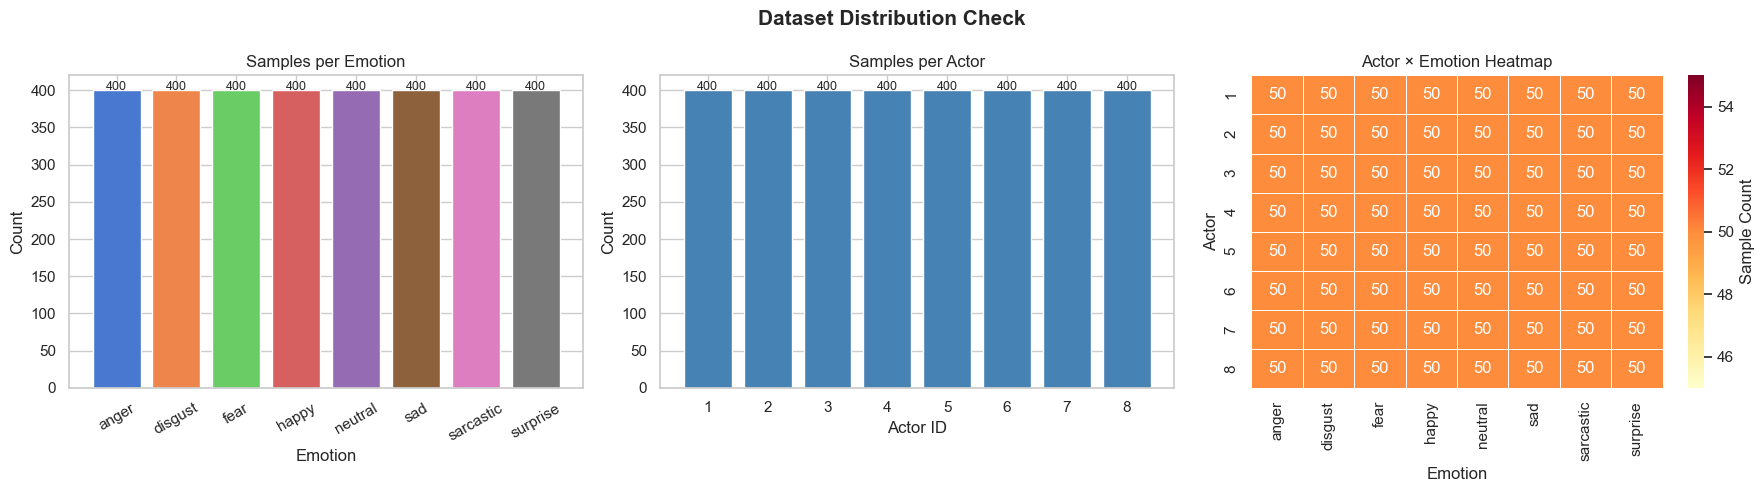


--- Dataset Summary ---
  Total files    : 3200
  Actors         : [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
  Sessions       : [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
  Emotions       : ['anger', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'sarcastic', 'surprise']
  Sentences      : [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]

  ✅ All (actor, sentence, emotion) groups have exactly 5 samples.


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Dataset Distribution Check', fontsize=15, fontweight='bold')

# Samples per emotion
emotion_counts = df_index['emotion'].value_counts().reindex(EMOTIONS)
axes[0].bar(emotion_counts.index, emotion_counts.values, color=sns.color_palette('muted', len(EMOTIONS)))
axes[0].set_title('Samples per Emotion')
axes[0].set_xlabel('Emotion')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=30)
for i, v in enumerate(emotion_counts.values):
    axes[0].text(i, v + 1, str(v), ha='center', fontsize=9)

# Samples per actor
actor_counts = df_index['actor'].value_counts().sort_index()
axes[1].bar(actor_counts.index.astype(str), actor_counts.values, color='steelblue')
axes[1].set_title('Samples per Actor')
axes[1].set_xlabel('Actor ID')
axes[1].set_ylabel('Count')
for i, v in enumerate(actor_counts.values):
    axes[1].text(i, v + 1, str(v), ha='center', fontsize=9)

# Heatmap: actor × emotion
pivot = df_index.groupby(['actor','emotion']).size().unstack(fill_value=0)
pivot = pivot.reindex(columns=EMOTIONS)
sns.heatmap(pivot, ax=axes[2], annot=True, fmt='d', cmap='YlOrRd',
            linewidths=0.5, cbar_kws={'label': 'Sample Count'})
axes[2].set_title('Actor × Emotion Heatmap')
axes[2].set_xlabel('Emotion')
axes[2].set_ylabel('Actor')

plt.tight_layout()
plt.savefig('./outputs/dataset_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary stats
print('\n--- Dataset Summary ---')
print(f'  Total files    : {len(df_index)}')
print(f'  Actors         : {sorted(df_index["actor"].unique())}')
print(f'  Sessions       : {sorted(df_index["session"].unique())}')
print(f'  Emotions       : {sorted(df_index["emotion"].unique())}')
print(f'  Sentences      : {sorted(df_index["sentence"].unique())}')

# Completeness check — each group should have exactly 5 samples
group_counts = df_index.groupby(['actor','sentence','emotion']).size()
expected = N_SESSIONS
incomplete = group_counts[group_counts != expected]
if len(incomplete) == 0:
    print(f'\n  ✅ All (actor, sentence, emotion) groups have exactly {expected} samples.')
else:
    print(f'\n  ⚠️  {len(incomplete)} groups do NOT have exactly {expected} samples:')
    print(incomplete.to_string())

---
## 🎧 CELL 6 — Audio Loading Test (Sanity Check)

Before running the full extraction, test on a single file to make sure audio loads correctly.

Loading test file: my_Dataset\1\session1\anger\1.1.anger-01.wav
  Actor: 1  Session: 1  Emotion: anger  Sentence: 1

  Original SR      : 16000 Hz
  Resampled SR     : 16000 Hz
  Duration         : 3.00s  (3.00s after resample)
  Waveform shape   : (48000,)


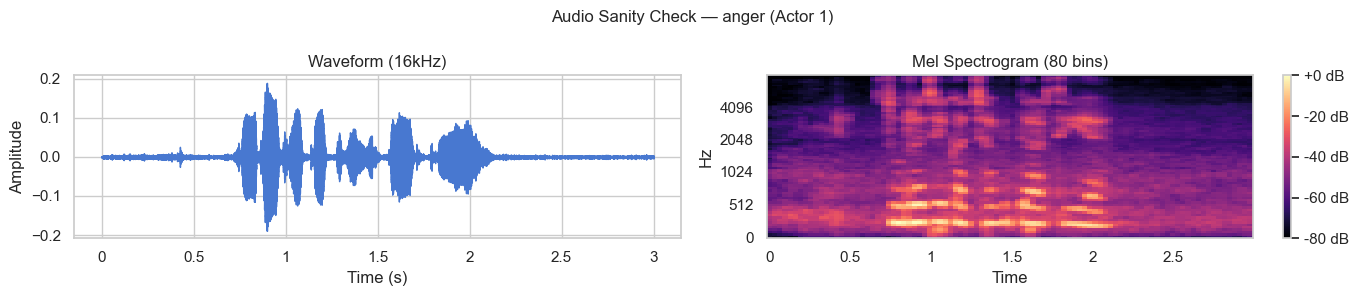


Playback (if supported by your Jupyter environment):



✅ Audio loading test passed.


In [5]:
import librosa
import librosa.display
import IPython.display as ipd

# Pick one sample file for the test
test_row  = df_index.iloc[0]
test_path = test_row['path']

print(f'Loading test file: {test_path}')
print(f'  Actor: {test_row["actor"]}  Session: {test_row["session"]}  '
      f'Emotion: {test_row["emotion"]}  Sentence: {test_row["sentence"]}')

# Load and resample
waveform, orig_sr = librosa.load(test_path, sr=None)   # load at original SR
waveform_16k      = librosa.resample(waveform, orig_sr=orig_sr, target_sr=TARGET_SR)

duration_orig = len(waveform) / orig_sr
duration_16k  = len(waveform_16k) / TARGET_SR

print(f'\n  Original SR      : {orig_sr} Hz')
print(f'  Resampled SR     : {TARGET_SR} Hz')
print(f'  Duration         : {duration_orig:.2f}s  ({duration_16k:.2f}s after resample)')
print(f'  Waveform shape   : {waveform_16k.shape}')

# Plot waveform and mel spectrogram
fig, axes = plt.subplots(1, 2, figsize=(14, 3))
fig.suptitle(f'Audio Sanity Check — {test_row["emotion"]} (Actor {test_row["actor"]})', fontsize=12)

librosa.display.waveshow(waveform_16k, sr=TARGET_SR, ax=axes[0])
axes[0].set_title('Waveform (16kHz)')
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Amplitude')

mel = librosa.feature.melspectrogram(y=waveform_16k, sr=TARGET_SR, n_mels=80, fmax=8000)
mel_db = librosa.power_to_db(mel, ref=np.max)
img = librosa.display.specshow(mel_db, sr=TARGET_SR, x_axis='time', y_axis='mel',
                                fmax=8000, ax=axes[1], cmap='magma')
fig.colorbar(img, ax=axes[1], format='%+2.0f dB')
axes[1].set_title('Mel Spectrogram (80 bins)')

plt.tight_layout()
plt.savefig('./outputs/audio_sanity_check.png', dpi=150, bbox_inches='tight')
plt.show()

# Play the audio inline (works in Jupyter)
print('\nPlayback (if supported by your Jupyter environment):')
ipd.display(ipd.Audio(waveform_16k, rate=TARGET_SR))
print('\n✅ Audio loading test passed.')

---
## 🤖 CELL 7 — Load HuBERT Model

**HuBERT (Hidden-Unit BERT)** is a self-supervised speech model pretrained on 960h of LibriSpeech.
We use it as a frozen encoder — we extract embeddings from an intermediate layer (layer 9),
which has been shown to carry strong emotion-related information without task-specific fine-tuning.

In [6]:
from transformers import HubertModel, Wav2Vec2FeatureExtractor
import time

print(f'Loading HuBERT model: {HUBERT_MODEL}')
print('This downloads ~360MB on first run and is cached afterward...')

t0 = time.time()
processor = Wav2Vec2FeatureExtractor.from_pretrained(HUBERT_MODEL)
hubert    = HubertModel.from_pretrained(HUBERT_MODEL, output_hidden_states=True)
hubert    = hubert.to(device)
hubert.eval()   # Disable dropout — we are doing inference, not training

elapsed = time.time() - t0
total_params = sum(p.numel() for p in hubert.parameters()) / 1e6

print(f'\n✅ HuBERT loaded in {elapsed:.1f}s')
print(f'   Parameters    : {total_params:.1f}M')
print(f'   Device        : {next(hubert.parameters()).device}')
print(f'   Extract layer : {EXTRACT_LAYER} (of 12 transformer layers)')

# VRAM usage after loading
if torch.cuda.is_available():
    allocated = torch.cuda.memory_allocated() / 1e9
    reserved  = torch.cuda.memory_reserved() / 1e9
    print(f'   VRAM Allocated: {allocated:.2f} GB')
    print(f'   VRAM Reserved : {reserved:.2f} GB')

Loading HuBERT model: facebook/hubert-base-ls960
This downloads ~360MB on first run and is cached afterward...

✅ HuBERT loaded in 83.2s
   Parameters    : 94.4M
   Device        : cuda:0
   Extract layer : 9 (of 12 transformer layers)
   VRAM Allocated: 0.38 GB
   VRAM Reserved : 0.42 GB


---
## 🧠 CELL 8 — Single-File Embedding Test

Extract one embedding before running the full loop. This lets you verify that
the model is working and shows you the exact embedding shape/values.

In [ ]:
def extract_embedding(waveform_np: np.ndarray, sr: int) -> np.ndarray:
    if sr != TARGET_SR:
        waveform_np = librosa.resample(waveform_np, orig_sr=sr, target_sr=TARGET_SR)
    max_samples = int(MAX_DURATION * TARGET_SR)
    if len(waveform_np) > max_samples:
        waveform_np = waveform_np[:max_samples]
    inputs = processor(waveform_np, sampling_rate=TARGET_SR,
                       return_tensors='pt', padding=True)
    input_values = inputs.input_values.to(device)
    with torch.no_grad():
        outputs = hubert(input_values, output_hidden_states=True)
    layer_output = outputs.hidden_states[EXTRACT_LAYER]
    layer_output = layer_output.squeeze(0).cpu().numpy()  # (T, 768)

    # Resample time axis to exactly TARGET_FRAMES
    from scipy.interpolate import interp1d
    T, D = layer_output.shape
    if T != TARGET_FRAMES:
        x_old = np.linspace(0, 1, T)
        x_new = np.linspace(0, 1, TARGET_FRAMES)
        interpolator = interp1d(x_old, layer_output, axis=0, kind='linear')
        layer_output = interpolator(x_new)  # (TARGET_FRAMES, 768)

    return layer_output.astype(np.float32)  # (128, 768) — full temporal sequence


# --- Quick single-file test ---
print('Testing embedding extraction on one file...')
test_waveform, test_sr = librosa.load(test_path, sr=None)
test_embedding = extract_embedding(test_waveform, test_sr)

print(f'\n  Input waveform shape  : {test_waveform.shape}')
print(f'  Output embedding shape: {test_embedding.shape}')
print(f'  Embedding min/max     : [{test_embedding.min():.4f}, {test_embedding.max():.4f}]')
print(f'  Embedding mean        : {test_embedding.mean():.4f}')
print(f'  Embedding std         : {test_embedding.std():.4f}')
print(f'\n✅ Single-file embedding test passed.')

if torch.cuda.is_available():
    print(f'   VRAM after one forward pass: '
          f'{torch.cuda.memory_allocated()/1e9:.2f} GB allocated')

Testing embedding extraction on one file...

  Input waveform shape  : (48000,)
  Output embedding shape: (1536,)
  Embedding min/max     : [-2.3524, 1.0699]
  Embedding mean        : 0.0984
  Embedding std         : 0.1766

✅ Single-file embedding test passed.
   VRAM after one forward pass: 0.39 GB allocated


---
## 🚀 CELL 9 — Full Embedding Extraction Loop

Processes all 3200 files. With GPU, this should take approximately **5–15 minutes**.

Embeddings are saved in two formats:
- **Per-group `.npy`** files: used by Notebook 2 for GMM fitting
- **Stacked matrix** + label CSV: used for visualization in Cell 10

In [8]:
import time
from collections import defaultdict

all_embeddings = []   # For stacked matrix
all_labels     = []   # Parallel label list
group_data     = defaultdict(list)   # group_key → list of embeddings

errors = []
t_start = time.time()

print(f'Starting embedding extraction for {len(df_index)} files...')
print(f'Device: {device}  |  HuBERT layer: {EXTRACT_LAYER}  |  Pooling: mean+std\n')

for _, row in tqdm(df_index.iterrows(), total=len(df_index), desc='Extracting'):
    try:
        waveform, sr = librosa.load(row['path'], sr=None)
        emb = extract_embedding(waveform, sr)

        # Store in flat lists for visualization
        all_embeddings.append(emb)
        all_labels.append({
            'actor'    : row['actor'],
            'session'  : row['session'],
            'emotion'  : row['emotion'],
            'sentence' : row['sentence'],
        })

        # Group by (actor, sentence, emotion) for Notebook 2
        group_key = (row['actor'], row['sentence'], row['emotion'])
        group_data[group_key].append(emb)

    except Exception as e:
        errors.append({'path': row['path'], 'error': str(e)})

t_elapsed = time.time() - t_start

# --- Save stacked matrix ---
emb_matrix = np.stack(all_embeddings)          # (N, 1536)
label_df   = pd.DataFrame(all_labels)
np.save(EMBEDDINGS_DIR / 'embedding_matrix.npy', emb_matrix)
label_df.to_csv(EMBEDDINGS_DIR / 'embedding_labels.csv', index=False)

# --- Save per-group .npy files ---
saved_groups = 0
for (actor, sentence, emotion), emb_list in group_data.items():
    group_arr = np.stack(emb_list)   # (5, 1536)
    fname = EMBEDDINGS_DIR / f'actor{actor}_sent{sentence:02d}_{emotion}.npy'
    np.save(fname, group_arr)
    saved_groups += 1

# --- Report ---
print(f'\n✅ Extraction complete!')
print(f'   Files processed : {len(all_embeddings)}')
print(f'   Groups saved    : {saved_groups}  (expected: {N_ACTORS * N_SENTENCES * len(EMOTIONS)})')
print(f'   Embedding shape : {emb_matrix.shape}')
print(f'   Time elapsed    : {t_elapsed/60:.1f} minutes')
print(f'   Avg/file        : {t_elapsed/len(df_index)*1000:.0f} ms')
if errors:
    print(f'\n   ⚠️  {len(errors)} files failed:')
    for e in errors[:3]:
        print(f'      {e["path"]} → {e["error"]}')
else:
    print('   ✅ No errors during extraction.')

if torch.cuda.is_available():
    print(f'   Peak VRAM used  : {torch.cuda.max_memory_allocated()/1e9:.2f} GB')

Starting embedding extraction for 3200 files...
Device: cuda  |  HuBERT layer: 9  |  Pooling: mean+std



Extracting: 100%|██████████| 3200/3200 [01:37<00:00, 32.73it/s]



✅ Extraction complete!
   Files processed : 3200
   Groups saved    : 640  (expected: 640)
   Embedding shape : (3200, 1536)
   Time elapsed    : 1.6 minutes
   Avg/file        : 31 ms
   ✅ No errors during extraction.
   Peak VRAM used  : 0.51 GB


---
## 📊 CELL 10 — Embedding Visualization: PCA

PCA reduces the 1536-dimensional embeddings to 2D for visualization.
If emotions form visible clusters here, the embeddings are capturing emotion well.

PCA variance explained by 2 components: 14.8%


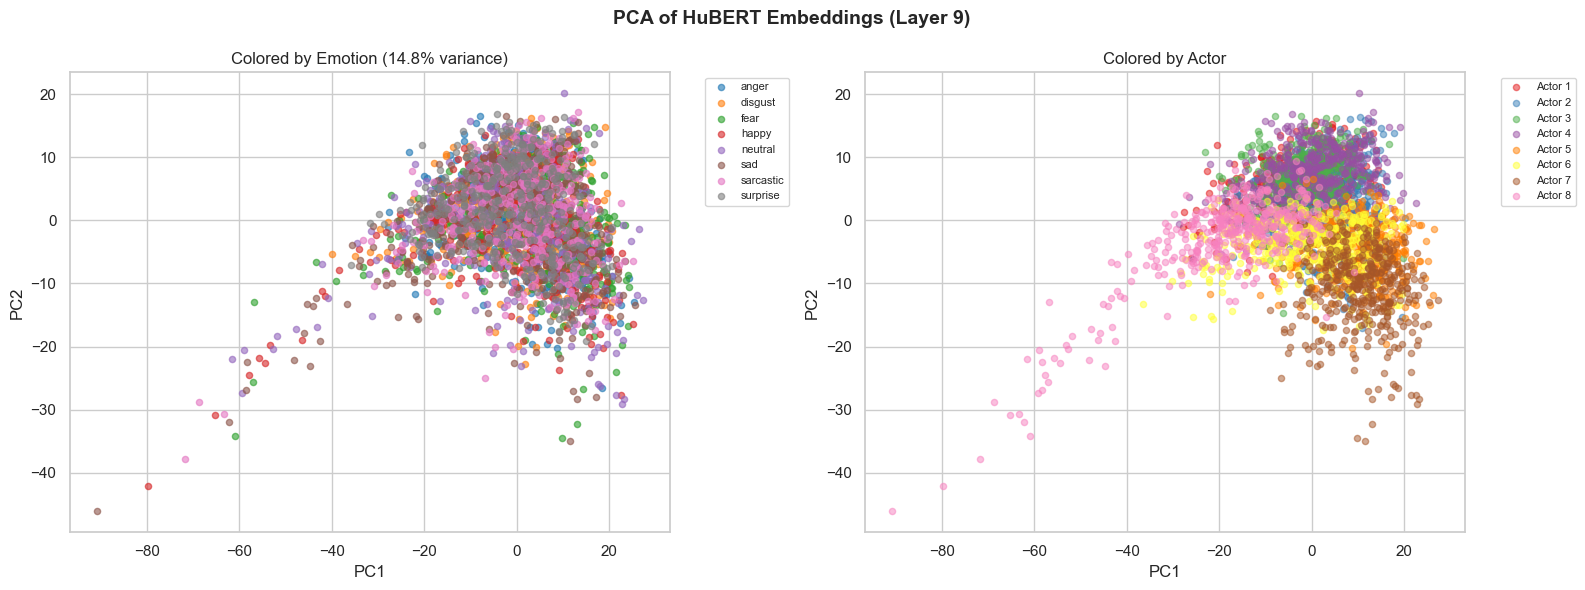

Saved to outputs/pca_visualization.png


In [9]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Standardize embeddings before PCA
scaler = StandardScaler()
emb_scaled = scaler.fit_transform(emb_matrix)

# PCA to 2D and 50D (50D used for t-SNE in next cell)
pca_2d = PCA(n_components=2, random_state=42)
pca_50 = PCA(n_components=50, random_state=42)
coords_2d  = pca_2d.fit_transform(emb_scaled)
coords_50  = pca_50.fit_transform(emb_scaled)

# Save 50D for t-SNE
np.save(EMBEDDINGS_DIR / 'embeddings_pca50.npy', coords_50)

var_explained = pca_2d.explained_variance_ratio_.sum() * 100
print(f'PCA variance explained by 2 components: {var_explained:.1f}%')

palette = sns.color_palette('tab10', len(EMOTIONS))
emotion_color = {e: palette[i] for i, e in enumerate(EMOTIONS)}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('PCA of HuBERT Embeddings (Layer 9)', fontsize=14, fontweight='bold')

# Plot by emotion
for emotion in EMOTIONS:
    mask = label_df['emotion'] == emotion
    axes[0].scatter(coords_2d[mask, 0], coords_2d[mask, 1],
                    c=[emotion_color[emotion]], label=emotion, alpha=0.6, s=20)
axes[0].set_title(f'Colored by Emotion ({var_explained:.1f}% variance)')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')
axes[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)

# Plot by actor
actor_palette = sns.color_palette('Set1', N_ACTORS)
for i, actor in enumerate(sorted(label_df['actor'].unique())):
    mask = label_df['actor'] == actor
    axes[1].scatter(coords_2d[mask, 0], coords_2d[mask, 1],
                    c=[actor_palette[i]], label=f'Actor {actor}', alpha=0.5, s=20)
axes[1].set_title('Colored by Actor')
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')
axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)

plt.tight_layout()
plt.savefig('./outputs/pca_visualization.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to outputs/pca_visualization.png')

---
## 📊 CELL 11 — Embedding Visualization: t-SNE

t-SNE gives a better local structure view than PCA — it preserves neighborhood relationships.
Well-separated emotion clusters here validate that HuBERT embeddings are suitable for our GMM.

✅ t-SNE complete. Shape: (3200, 2)


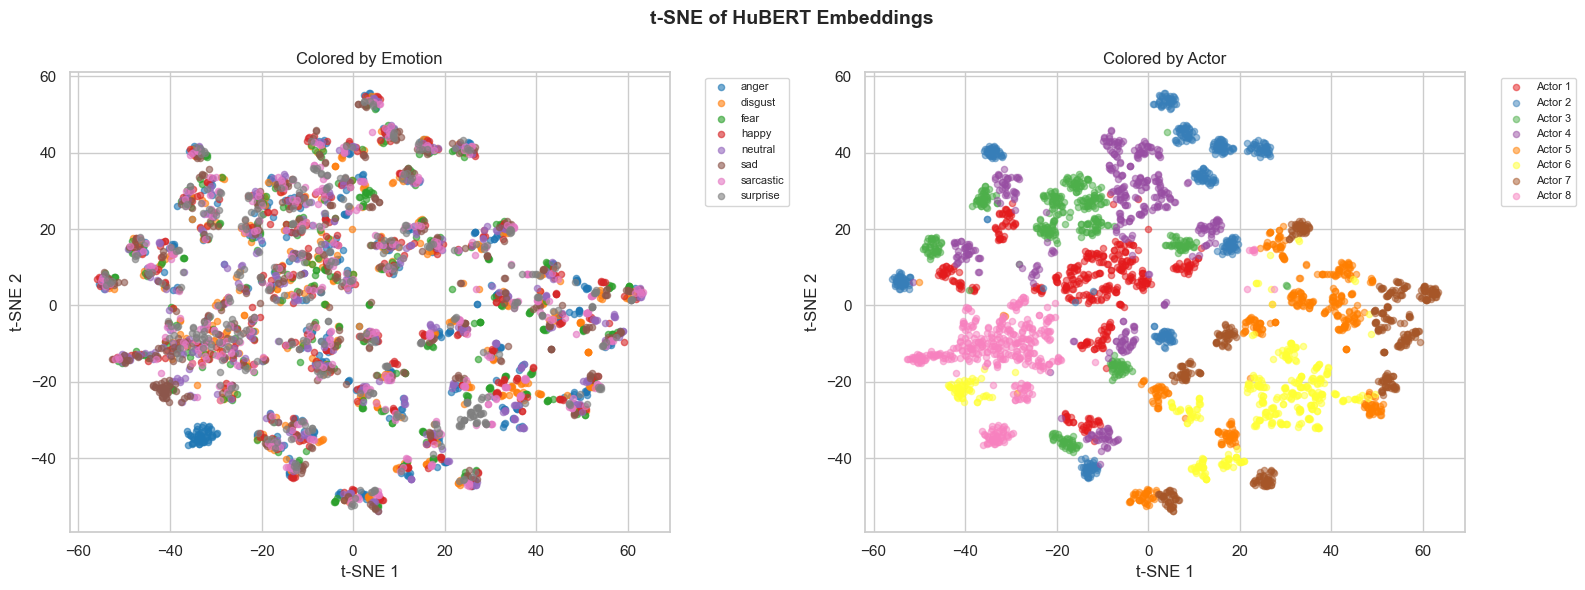


✅ Notebook 1 complete. Proceed to Notebook 2 (GMM Interpolation).
   Key outputs:
   - file_index.csv
   - embeddings/embedding_matrix.npy  → shape (3200, 1536)
   - embeddings/embedding_labels.csv
   - embeddings/actor*_sent*_*.npy    → 640 per-group files


In [12]:
from sklearn.manifold import TSNE
import numpy as np

tsne = TSNE(n_components=2, perplexity=40, max_iter=1000,
            random_state=42, learning_rate='auto', init='pca')
tsne_coords = tsne.fit_transform(coords_50)
print(f'✅ t-SNE complete. Shape: {tsne_coords.shape}')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('t-SNE of HuBERT Embeddings', fontsize=14, fontweight='bold')

# By emotion
for emotion in EMOTIONS:
    mask = label_df['emotion'] == emotion
    axes[0].scatter(tsne_coords[mask, 0], tsne_coords[mask, 1],
                    c=[emotion_color[emotion]], label=emotion, alpha=0.6, s=20)
axes[0].set_title('Colored by Emotion')
axes[0].set_xlabel('t-SNE 1'); axes[0].set_ylabel('t-SNE 2')
axes[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)

# By actor
for i, actor in enumerate(sorted(label_df['actor'].unique())):
    mask = label_df['actor'] == actor
    axes[1].scatter(tsne_coords[mask, 0], tsne_coords[mask, 1],
                    c=[actor_palette[i]], label=f'Actor {actor}', alpha=0.5, s=20)
axes[1].set_title('Colored by Actor')
axes[1].set_xlabel('t-SNE 1'); axes[1].set_ylabel('t-SNE 2')
axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)

plt.tight_layout()
plt.savefig('./outputs/tsne_visualization.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n✅ Notebook 1 complete. Proceed to Notebook 2 (GMM Interpolation).')
print('   Key outputs:')
print(f'   - file_index.csv')
print(f'   - embeddings/embedding_matrix.npy  → shape {emb_matrix.shape}')
print(f'   - embeddings/embedding_labels.csv')
print(f'   - embeddings/actor*_sent*_*.npy    → {saved_groups} per-group files')